# Customer Feedback Analytics System
## Module 2: Sentiment Analysis & Keyword Extraction

Uses VADER (Valence Aware Dictionary and sEntiment Reasoner) to score the
sentiment of each product's combined review text, and extracts the most
frequent meaningful keywords separately from positive vs. negative reviews.

VADER is well-suited here because it's tuned for informal, review-style text
(handles negation, intensifiers like "very", punctuation emphasis, and emoji)
rather than requiring a trained model — appropriate given the short project
timeline.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option('display.max_colwidth', 80)
analyzer = SentimentIntensityAnalyzer()

## Part 1: Load Cleaned Data

In [3]:
df = pd.read_csv("data/cleaned_feedback_data.csv")
print("Shape:", df.shape)
df[["product_id", "product_name", "rating", "review_text_full"]].head(3)

Shape: (1350, 13)


,product_id,product_name,rating,review_text_full
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Comp...,4.2,"Satisfied,Charging is really fast,Value for money,Product review,Good qualit..."
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Sma...,4.0,"A Good Braided Cable for Your Type C Device,Good quality product from ambran..."
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone...,3.9,"Good speed for earlier versions,Good Product,Working good,Good for the price..."


## Part 2: Apply VADER Sentiment Scoring

VADER returns a `compound` score from -1 (most negative) to +1 (most positive).
Standard thresholds:
- compound >= 0.05 -> Positive
- compound <= -0.05 -> Negative
- otherwise -> Neutral

In [4]:
def get_sentiment(text):
    if pd.isna(text) or text.strip() == "":
        return pd.Series({"vader_compound": 0.0, "vader_pos": 0.0,
                           "vader_neu": 0.0, "vader_neg": 0.0})
    scores = analyzer.polarity_scores(text)
    return pd.Series({
        "vader_compound": scores["compound"],
        "vader_pos": scores["pos"],
        "vader_neu": scores["neu"],
        "vader_neg": scores["neg"],
    })

# Drop these columns first if they already exist, so re-running this cell is safe
df = df.drop(columns=["vader_compound", "vader_pos", "vader_neu", "vader_neg"], errors="ignore")

sentiment_scores = df["review_text_full"].apply(get_sentiment)
df = pd.concat([df, sentiment_scores], axis=1)

def sentiment_label(compound):
    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["vader_compound"].apply(sentiment_label)

print(df["sentiment_label"].value_counts())
df[["product_name", "rating", "vader_compound", "sentiment_label"]].head(5)

sentiment_label
Positive    1300
Negative      47
Neutral        3
Name: count, dtype: int64


,product_name,rating,vader_compound,sentiment_label
0,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Comp...,4.2,0.9297,Positive
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Sma...,4.0,0.9937,Positive
2,Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone...,3.9,0.8976,Positive
3,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, ...",4.2,0.9854,Positive
4,Portronics Konnect L 1.2M Fast Charging 3A 8 Pin USB Cable with Charge & Syn...,4.2,0.9958,Positive


## Part 3: Validate Sentiment Against Star Rating

If VADER sentiment is working correctly, it should broadly agree with the
numeric star rating - high ratings should skew Positive, low ratings should
skew Negative. This cross-check is useful evidence for the Testing chapter.

In [6]:
validation = df.groupby("sentiment_label")["rating"].agg(["mean", "count"]).round(2)
validation = validation.sort_values("mean", ascending=False)
print(validation)

# Correlation between VADER compound score and star rating
corr = df["vader_compound"].corr(df["rating"])
print(f"\nCorrelation between VADER sentiment and star rating: {corr:.3f}")

                 mean  count
sentiment_label             
Positive         4.10   1300
Negative         3.86     47
Neutral          3.57      3

Correlation between VADER sentiment and star rating: 0.218


## Part 4: Keyword Extraction - Positive vs Negative Reviews

Extract the most frequent meaningful words (unigrams and bigrams) separately
for reviews classified as Positive vs Negative, using CountVectorizer with
English stopwords removed. This surfaces what customers actually praise or
complain about.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Domain-generic words that appear everywhere and add no insight
custom_stopwords = ["good", "product", "products", "use", "used", "using",
                     "item", "items", "buy", "bought", "amazon", "price"]

from sklearn.feature_extraction import text
all_stopwords = list(text.ENGLISH_STOP_WORDS.union(custom_stopwords))

def top_keywords_tfidf(text_series, n=20, ngram_range=(1, 2)):
    vectorizer = TfidfVectorizer(
        stop_words=all_stopwords,
        ngram_range=ngram_range,
        max_features=5000,
        min_df=2
    )
    X = vectorizer.fit_transform(text_series.dropna())
    scores = np.asarray(X.sum(axis=0)).flatten()
    vocab = vectorizer.get_feature_names_out()
    freq_df = pd.DataFrame({"keyword": vocab, "tfidf_score": scores})
    return freq_df.sort_values("tfidf_score", ascending=False).head(n).reset_index(drop=True)

positive_text = df[df["sentiment_label"] == "Positive"]["review_text_full"]
negative_text = df[df["sentiment_label"] == "Negative"]["review_text_full"]

top_positive_keywords = top_keywords_tfidf(positive_text, n=20)
top_negative_keywords = top_keywords_tfidf(negative_text, n=20)

print("TOP POSITIVE KEYWORDS (TF-IDF):")
print(top_positive_keywords)
print("\nTOP NEGATIVE KEYWORDS (TF-IDF):")
print(top_negative_keywords)

top_positive_keywords.to_csv("data/top_positive_keywords.csv", index=False)
top_negative_keywords.to_csv("data/top_negative_keywords.csv", index=False)

TOP POSITIVE KEYWORDS (TF-IDF):
        keyword  tfidf_score
0       quality    66.253744
1          nice    54.057003
2         cable    50.240313
3          easy    41.217504
4         money    39.816956
5      charging    38.072586
6         value    36.003960
7          best    35.136331
8       working    34.088604
9         phone    33.855496
10  value money    33.789949
11           tv    32.200719
12         like    31.511014
13      battery    28.836112
14        sound    28.454010
15           ok    28.450275
16        great    28.126823
17        works    27.894952
18        watch    26.867812
19        worth    26.273575

TOP NEGATIVE KEYWORDS (TF-IDF):
        keyword  tfidf_score
0       working     3.236533
1       quality     3.051521
2           bad     2.441514
3            tv     2.426542
4          nice     2.211552
5         cable     2.178321
6       battery     2.124174
7         money     2.117332
8       service     1.988172
9          like     1.740452
10     

## Part 5: Sentiment by Category and Price Tier

Cross-tabulate sentiment with product category and price tier - useful for
identifying which segments generate the most negative feedback.

In [15]:
sentiment_by_category = pd.crosstab(df["main_category"], df["sentiment_label"], normalize="index") * 100
sentiment_by_category = sentiment_by_category.round(1)
print("Sentiment distribution (%) by category:")
print(sentiment_by_category.sort_values("Negative", ascending=False))

sentiment_by_category.to_csv("data/sentiment_by_category.csv")

Sentiment distribution (%) by category:
sentiment_label        Negative  Neutral  Positive
main_category                                     
Home&Kitchen                3.8      0.2      96.0
Electronics                 3.5      0.0      96.5
Computers&Accessories       3.2      0.5      96.3
OfficeProducts              3.2      0.0      96.8
Car&Motorbike               0.0      0.0     100.0
Health&PersonalCare         0.0      0.0     100.0
HomeImprovement             0.0      0.0     100.0
MusicalInstruments          0.0      0.0     100.0
Toys&Games                  0.0      0.0     100.0


## Part 6: Save Enriched Dataset

In [16]:
df.to_csv("data/feedback_with_sentiment.csv", index=False)
print("Saved feedback_with_sentiment.csv:", df.shape)

Saved feedback_with_sentiment.csv: (1350, 18)


## Part 7: Visualizations

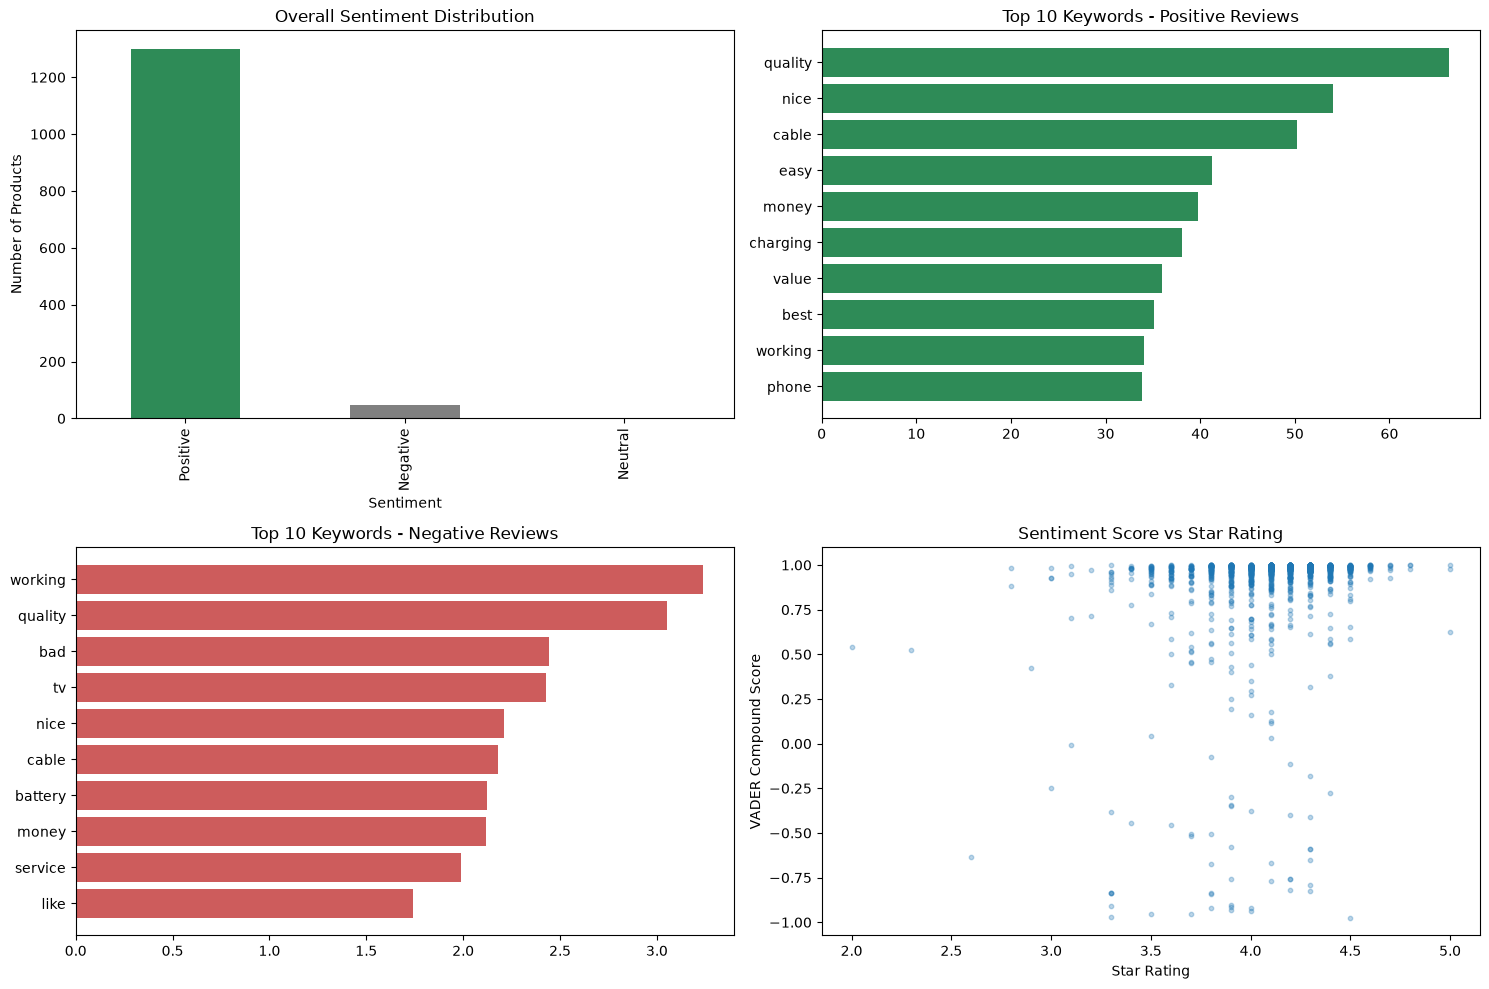

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sentiment distribution
df["sentiment_label"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["seagreen", "gray", "indianred"])
axes[0, 0].set_title("Overall Sentiment Distribution")
axes[0, 0].set_xlabel("Sentiment")
axes[0, 0].set_ylabel("Number of Products")

# Top positive keywords
axes[0, 1].barh(top_positive_keywords["keyword"][:10][::-1], top_positive_keywords["tfidf_score"][:10][::-1], color="seagreen")
axes[0, 1].set_title("Top 10 Keywords - Positive Reviews")

# Top negative keywords
axes[1, 0].barh(top_negative_keywords["keyword"][:10][::-1], top_negative_keywords["tfidf_score"][:10][::-1], color="indianred")
axes[1, 0].set_title("Top 10 Keywords - Negative Reviews")

# Sentiment vs rating scatter
axes[1, 1].scatter(df["rating"], df["vader_compound"], alpha=0.3, s=10)
axes[1, 1].set_xlabel("Star Rating")
axes[1, 1].set_ylabel("VADER Compound Score")
axes[1, 1].set_title("Sentiment Score vs Star Rating")

plt.tight_layout()
plt.savefig("data/sentiment_charts.png", dpi=150)
plt.show()